In [ ]:
#!pip install arch

In [1]:
from arch import arch_model
import pandas as pd
import wrds
import numpy as np
import yfinance as yf

/Users/nasruddinislambinramli/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [ ]:
nasbramlidb =\
(
    wrds
    .Connection()
)

In [ ]:
fama_french_query =\
(
    """
    SELECT date, mktrf, smb, hml, rf 
    FROM ff.factors_monthly
    WHERE date >= '2000-01-01' AND date < '2024-01-01'
    """
)

In [ ]:
ff_df =\
(
    db
    .raw_sql(fama_french_query)
)

In [ ]:
(
    ff_df
    .to_csv('fama_french.csv', index = False)
)

In [2]:
fama_french =\
(
    pd
    .read_csv('fama_french.csv')
)

FileNotFoundError: [Errno 2] No such file or directory: 'fama_french.csv'

In [ ]:
fama_french["Date"]=\
(
    fama_french
    .date
    .apply(lambda x: str(x)
          )
)

fama_french["Date"]=\
(
    pd
    .to_datetime(fama_french.Date,
                 format="%Y-%m-%d"
                )
)

fama_french =\
(
    fama_french
    .set_index("Date", inplace = False)
)


In [ ]:
russell = {}

for key in keys:
    
    data =\
    (
        pd
        .read_hdf('all_tickers_time_series.hf5', 
                  key=key)
    )
    
    if isinstance(data, pd.Series):
        
        data =\
        (
            data
            .to_frame()
        )
        
    data =\
    (
        data
        .drop_duplicates()
    )
    
    data =\
    (
        data
        .dropna()
    )
    
    if isinstance(data, pd.DataFrame) and 'date' in data.columns:
        data['Date'] =\
        (
            pd
            .to_datetime(data['date'], 
                         format="%Y-%m-%d")
        )
        
        data =\
        (
            data
            .drop(columns=['date'])
        )
        
        data =\
        (
            data
            .set_index('Date')
        )
    
    
    russell[key] = data

In [ ]:
stock_data = {}

In [ ]:
for ticker, data in russell.items():

    df =\
    (
        pd
        .DataFrame(data)
    )

    print(f"Columns for {ticker}: {df.columns.tolist()}")
    
    if 'prc' in df.columns:
        
        df['returns'] =\
        (
            np.log(df['prc']
                   /
                   df['prc'].shift(1)
                  )
        )
        
        df['r_vol'] =\
        (
            df['returns']
            .rolling(window = 252)
            .std()
            *
            np
            .sqrt
            (252)
        )
        
        
        stock_data[ticker] = df
    else:
        print(f"'prc' column not found for {ticker}. Available columns: {df.columns.tolist()}")


In [ ]:
# Check for duplicates in returns
for ticker, data in stock_data.items():
    
    r_vol =\
    (
        data['r_vol']
    )
    
    # Check for duplicates
    if r_vol.index.duplicated().any():
        
        print(f"Duplicates found in returns for {ticker}. Resolving...")
        
        r_vol =\
        (
            r_vol[~r_vol.index.duplicated(keep='first')]  # Keep the first occurrence
        )
        
    # Check for duplicates in Fama-French factors
    if fama_french.index.duplicated().any():
        
        print("Duplicates found in Fama-French factors. Resolving...")
        
        fama_french =\
        (
            fama_french[~fama_french.index.duplicated(keep='first')]  # Keep the first occurrence
        )

    # Align with Fama-French factors
    aligned_r_vol =\
    (
        r_vol
        .reindex(fama_french.index)
        .dropna()
    )
    
    aligned_factors =\
    (
        fama_french
        .loc[aligned_r_vol.index] # Align factors with returns
    )

    # Now both aligned_returns and aligned_factors have the same index
    print(f"Aligned returns for {ticker}:\n{aligned_r_vol.head()}")
    
    print(f"Aligned Fama-French factors:\n{aligned_factors.head()}")
    
    # Fit the GARCH-X model
    model =\
    (
        arch_model(aligned_r_vol,
                   vol='Garch',
                   p=1, 
                   q=1,
                   x=aligned_factors.values,
                   dist='Normal')
    )
    
    try:
        results =\
        (
            model
            .fit(disp='off')
        )
        
        print(f"Results for {ticker}:")
        
        print(results.summary())
        
    except Exception as e:
        
        print(f"Error fitting GARCH model for {ticker}: {e}")


In [ ]:
for ticker, data in stock_data.items():
    
    r_vol = data['r_vol']
    
    if r_vol.index.duplicated().any():
        print(f"Duplicates found in returns for {ticker}. Resolving...")
        r_vol =\
        (
            r_vol
            [~r_vol.index.duplicated(keep='first')]
        )
    
    if fama_french.index.duplicated().any():
        print("Duplicates found in Fama-French factors. Resolving...")
        fama_french =\
        (
            fama_french
            [~fama_french.index.duplicated(keep='first')]
        )

    r_vol.index =\
    (
        pd
        .to_datetime
        (r_vol.index)
    )
    
    fama_french.index =\
    (
        pd
        .to_datetime
        (fama_french.index)
    )
    
    aligned_factors =\
    (
        pd
        .merge_asof(r_vol.sort_index(), 
                    fama_french.sort_index(), 
                    left_index=True, 
                    right_index=True, 
                    direction='backward')
    )
    
    aligned_factors =\
    (
        aligned_factors
        .dropna()
    )

    aligned_r_vol =\
    (
        r_vol
        .loc
        [aligned_factors.index]
    )

    print(f"Aligned returns for {ticker}:\n{aligned_r_vol.head()}")
    
    print(f"Aligned Fama-French factors:\n{aligned_factors.head()}")
    
    model =\
    (
        arch_model(aligned_r_vol,
                   vol='Garch',
                   p=1, 
                   q=1,
                   x=aligned_factors.values,
                   dist='Normal')
    )
    
    try:
        results =\
        (
            model
            .fit
            (disp='off')
        )
        
        print(f"Results for {ticker}:")
        
        print(results.summary())
        
    except Exception as e:
        
        print(f"Error fitting GARCH model for {ticker}: {e}")

In [3]:
start= '2000-01-01'
end= '2024-01-01'

In [4]:
xlu =\
(
    yf
    .download('XLU',
              start, 
              end)
)

[*********************100%%**********************]  1 of 1 completed


In [5]:
xlu

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2000-01-03,28.937500,28.937500,27.218750,27.453125,11.514970,176700
2000-01-04,27.468750,27.468750,26.625000,26.625000,11.167623,93500
2000-01-05,27.218750,27.421875,26.859375,27.296875,11.449433,273400
2000-01-06,27.250000,27.250000,26.937500,27.250000,11.429772,34500
2000-01-07,27.296875,27.484375,27.171875,27.484375,11.528079,46200
...,...,...,...,...,...,...
2023-12-22,62.639999,63.240002,62.500000,62.619999,61.195446,13223700
2023-12-26,62.520000,63.240002,62.500000,63.000000,61.566803,9537500
2023-12-27,62.880001,63.080002,62.639999,62.959999,61.527714,9492200


In [6]:
log_ret=\
(
    np
    .log(xlu
         /xlu.shift(1))
    .dropna()
)

In [7]:
log_returns =\
(
    log_ret
    ['Adj Close']
)

In [8]:
log_returns =\
(
    pd
    .Series(log_returns)
)

In [9]:
figarch_model =\
(
    arch_model(log_returns, 
               vol='FIGARCH',
               p=1,
               q=1)
)

In [10]:
figarch_result =\
(
    figarch_model.fit()
)

/Users/nasruddinislambinramli/anaconda3/lib/python3.11/site-packages/arch/univariate/base.py:311: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0001515. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(


Iteration:      1,   Func. Count:      7,   Neg. LLF: 113739552616.2877
Iteration:      2,   Func. Count:     22,   Neg. LLF: 874463432.4241109
Iteration:      3,   Func. Count:     37,   Neg. LLF: 442420.22499893035
Optimization terminated successfully    (Exit mode 0)
            Current function value: -19184.403962503835
            Iterations: 3
            Function evaluations: 45
            Gradient evaluations: 3


In [11]:
print(figarch_result.summary())

                    Constant Mean - FIGARCH Model Results                     
Dep. Variable:              Adj Close   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                    FIGARCH   Log-Likelihood:                19184.4
Distribution:                  Normal   AIC:                          -38358.8
Method:            Maximum Likelihood   BIC:                          -38325.3
                                        No. Observations:                 6036
Date:                Sat, Oct 26 2024   Df Residuals:                     6035
Time:                        21:41:59   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu         5.2639e-04  9.898e-05      5.318  1.049e-07 [3.

In [12]:
predicted_volatility =\
(
    figarch_result
    .conditional_volatility
)

In [13]:
predicted_volatility

Date
2000-01-04    0.016311
2000-01-05    0.017750
2000-01-06    0.018361
2000-01-07    0.018072
2000-01-10    0.017717
                ...   
2023-12-22    0.013639
2023-12-26    0.013164
2023-12-27    0.012568
2023-12-28    0.011863
2023-12-29    0.011341
Name: cond_vol, Length: 6036, dtype: float64

In [14]:
rmse =\
(
    np
    .sqrt(np.mean((log_returns - predicted_volatility) ** 2))
)

In [15]:
def smape(actual, predicted):
    return 100 * np.mean(np.abs(actual - predicted) / ((np.abs(actual) + np.abs(predicted)) / 2))

In [16]:
smape_value =\
(
    smape(log_returns, 
          predicted_volatility)
)

In [17]:
print(rmse)
print(smape_value)

0.017276989594216356
130.48927744706677


In [18]:
garch_model =\
(
    arch_model(log_returns, 
               vol='Garch',
               p=1,
               q=1)
)

In [19]:
import matplotlib.pyplot as plt

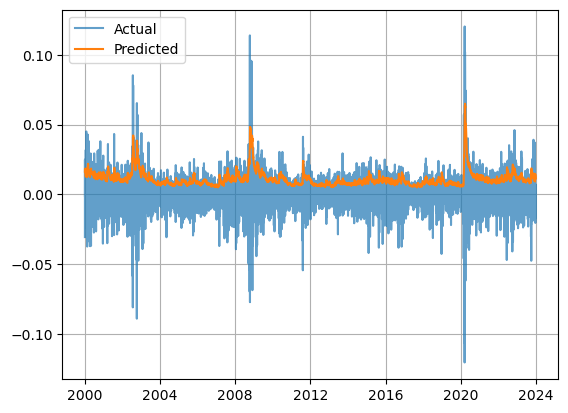

In [20]:
plt\
    .plot(log_returns, alpha = 0.7, label ='Actual')

plt\
    .plot(predicted_volatility, label = 'Predicted')

plt\
    .grid()

plt\
    .legend()

In [21]:
log_returns

Date
2000-01-04   -0.030629
2000-01-05    0.024921
2000-01-06   -0.001719
2000-01-07    0.008564
2000-01-10    0.003405
                ...   
2023-12-22    0.003359
2023-12-26    0.006050
2023-12-27   -0.000635
2023-12-28    0.007122
2023-12-29   -0.001262
Name: Adj Close, Length: 6036, dtype: float64

In [22]:
rolling_window = 5
predictions = []


for i in range(rolling_window, len(log_returns)):
    
    model =\
    (
        arch_model(log_returns[i-rolling_window:i],
                   vol='FIGARCH',
                   p=1,
                   q=1)
    )
    
    model_fit =\
    (
        model
        .fit(disp="off")
    )
    
    forecast =\
    (
        model_fit
        .forecast(horizon=1)
    )
    
    date =\
    (
        log_returns
        .index[i]
    )
    
    prediction =\
    (
        forecast
        .variance.values[0][0]
    )
    
    predictions.append((date, prediction))


/Users/nasruddinislambinramli/anaconda3/lib/python3.11/site-packages/arch/univariate/base.py:311: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0003286. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
/Users/nasruddinislambinramli/anaconda3/lib/python3.11/site-packages/arch/univariate/base.py:311: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0001415. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
/Users/nasruddinislambin

/Users/nasruddinislambinramli/anaconda3/lib/python3.11/site-packages/arch/univariate/base.py:311: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 3.892e-06. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 1000 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
/Users/nasruddinislambinramli/anaconda3/lib/python3.11/site-packages/arch/univariate/base.py:311: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 7.599e-06. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 1000 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
/Users/nasruddinislamb

/Users/nasruddinislambinramli/anaconda3/lib/python3.11/site-packages/arch/univariate/base.py:311: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0001752. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
/Users/nasruddinislambinramli/anaconda3/lib/python3.11/site-packages/arch/univariate/base.py:311: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0005592. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
/Users/nasruddinislambin

/Users/nasruddinislambinramli/anaconda3/lib/python3.11/site-packages/arch/univariate/base.py:311: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 6.276e-05. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
/Users/nasruddinislambinramli/anaconda3/lib/python3.11/site-packages/arch/univariate/base.py:311: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 4.859e-05. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
/Users/nasruddinislambin

/Users/nasruddinislambinramli/anaconda3/lib/python3.11/site-packages/arch/univariate/base.py:311: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0003823. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
/Users/nasruddinislambinramli/anaconda3/lib/python3.11/site-packages/arch/univariate/base.py:311: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0002758. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
/Users/nasruddinislambin

...

/Users/nasruddinislambinramli/anaconda3/lib/python3.11/site-packages/arch/univariate/base.py:311: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 3.668e-05. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
/Users/nasruddinislambinramli/anaconda3/lib/python3.11/site-packages/arch/univariate/base.py:311: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 2.093e-05. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
/Users/nasruddinislambin

/Users/nasruddinislambinramli/anaconda3/lib/python3.11/site-packages/arch/univariate/base.py:311: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0001329. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
/Users/nasruddinislambinramli/anaconda3/lib/python3.11/site-packages/arch/univariate/base.py:311: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0001212. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
/Users/nasruddinislambin

/Users/nasruddinislambinramli/anaconda3/lib/python3.11/site-packages/arch/univariate/base.py:311: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 6.083e-05. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
/Users/nasruddinislambinramli/anaconda3/lib/python3.11/site-packages/arch/univariate/base.py:766: ConvergenceWarning: The optimizer returned code 9. The message is:
Iteration limit reached
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(
/Users/nasruddinislambinramli/anaconda3/lib/python3.11/site-packages/arch/univariate/base.py:311: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 7.84e-06. Parameter

/Users/nasruddinislambinramli/anaconda3/lib/python3.11/site-packages/arch/univariate/base.py:311: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0003005. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
/Users/nasruddinislambinramli/anaconda3/lib/python3.11/site-packages/arch/univariate/base.py:311: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0003032. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
/Users/nasruddinislambin

/Users/nasruddinislambinramli/anaconda3/lib/python3.11/site-packages/arch/univariate/base.py:311: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0003749. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
/Users/nasruddinislambinramli/anaconda3/lib/python3.11/site-packages/arch/univariate/base.py:311: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0003741. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
/Users/nasruddinislambin

In [23]:
actual_returns =\
(
    log_returns[rolling_window:]
)

In [45]:
predictions_df =\
(
    pd
    .DataFrame(predictions,
               columns=['Date',
                        'Predicted'])
)

predictions_df.set_index('Date', inplace=True)

In [46]:
predictions_df

,Predicted
Date,
2000-01-11,0.000040
2000-01-12,0.000141
2000-01-13,0.000059
2000-01-14,0.000065
2000-01-18,0.000063
...,...
2023-12-22,0.000108
2023-12-26,0.000090
2023-12-27,0.000100


In [47]:
predicted_volatility =\
(
    np
    .sqrt(predictions_df) 
)

In [48]:
prediction_dates =\
(
    actual_returns.index
)

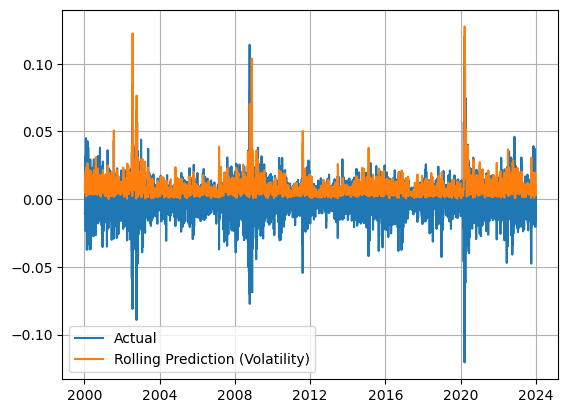

In [49]:
plt\
    .plot(actual_returns.index,
          actual_returns.values,
          label='Actual')

plt\
    .plot(prediction_dates,
          predicted_volatility,
          label='Rolling Prediction (Volatility)')

plt\
    .grid()

plt\
    .legend()

In [50]:
predicted_volatility

,Predicted
Date,
2000-01-11,0.006307
2000-01-12,0.011895
2000-01-13,0.007675
2000-01-14,0.008093
2000-01-18,0.007965
...,...
2023-12-22,0.010380
2023-12-26,0.009478
2023-12-27,0.010005


In [52]:
roll_smape =\
(
    smape(actual_returns, predicted_volatility['Predicted'])
)

In [55]:
rmse_roll =\
(
    np.sqrt(np.mean((actual_returns.values - predicted_volatility['Predicted']) ** 2))
)

In [56]:
print(roll_smape)
print(rmse_roll)

131.2551675696417
0.016709337068637156


In [58]:
predictions_df\
    .to_csv('XLU_figarch_Nas.csv',
            index = True)